## 🔍 Part 4: Exploratory Data Analysis 
In this section, we transition from Data Engineering to Data Science. To avoid data leakage and build a realistic predictive model for academic risk, we categorize our features into two groups:
1. **Day-1 Predictors:** Background and lifestyle metrics available on the first day of class.
2. **Mid-Term Trackers:** Temporal grade tracking updates ($G1$, $G2$).

We will query SQLite database directly to analyze feature distributions, identify data anomalies, and evaluate correlation strengths.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Connect to the database and pull a unified analytical dataset
conn = sqlite3.connect("student_records.db")
query = """
SELECT 
    c.student_id, c.age, c.sex, c.address,
    b.Medu, b.Fedu, b.schoolsup, b.famsup,
    l.studytime, l.goout, l.Dalc, l.Walc, l.health,
    p.failures, p.absences, p.G1, p.G2, p.G3
FROM STUDENT_CORE c
JOIN STUDENT_BACKGROUND b ON c.student_id = b.student_id
JOIN STUDENT_LIFESTYLE l  ON c.student_id = l.student_id
JOIN STUDENT_PERFORMANCE p ON c.student_id = p.student_id;
"""

df_analytical = pd.read_sql_query(query, conn)
conn.close()

print(f"📊 Successfully extracted {df_analytical.shape[0]} rows and {df_analytical.shape[1]} columns for EDA via SQL Joins.")

📊 Successfully extracted 395 rows and 18 columns for EDA via SQL Joins.


### 📈 1. Univariate Analysis: Target Variable Distribution & The "Zero-Grade Anomaly"
Before analyzing predictors, we must understand our target variable (`G3`). A common trap in this dataset is a sharp spike of students scoring exactly 0. We need to look closely at this drop-out pattern.

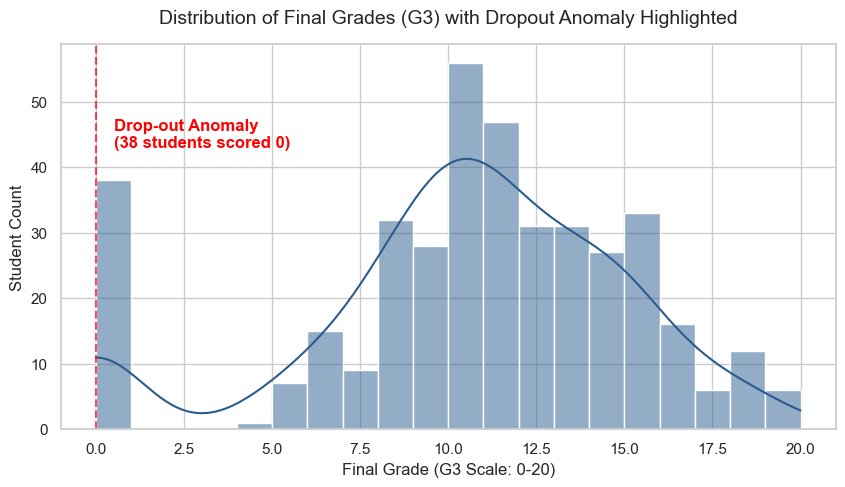

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_analytical['G3'], kde=True, bins=20, color="#2b5c8f", ax=ax)

# Highlight the anomaly
zero_count = (df_analytical['G3'] == 0).sum()
ax.axvline(x=0, color="red", linestyle="--", alpha=0.7)
ax.text(0.5, zero_count + 5, f"Drop-out Anomaly\n({zero_count} students scored 0)", color="red", weight="bold")

ax.set_title("Distribution of Final Grades (G3) with Dropout Anomaly Highlighted", fontsize=14, pad=15)
ax.set_xlabel("Final Grade (G3 Scale: 0-20)")
ax.set_ylabel("Student Count")
plt.show()

### 🕵️‍♂️ 2. Bivariate Analysis: Day-1 Predictors vs. Mid-Term Trackers

To show the practical utility of the future model, we evaluate:
* How structural lifestyle components (like past class failures or social habits) impact final grades before the semester even starts.
* How heavily $G1$ and $G2$ dominate final scores, validating our decision to treat them separately.

C:\Users\User\AppData\Local\Temp\ipykernel_7508\2703927895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failures', y='G3', data=df_analytical, ax=ax1, palette="Blues")


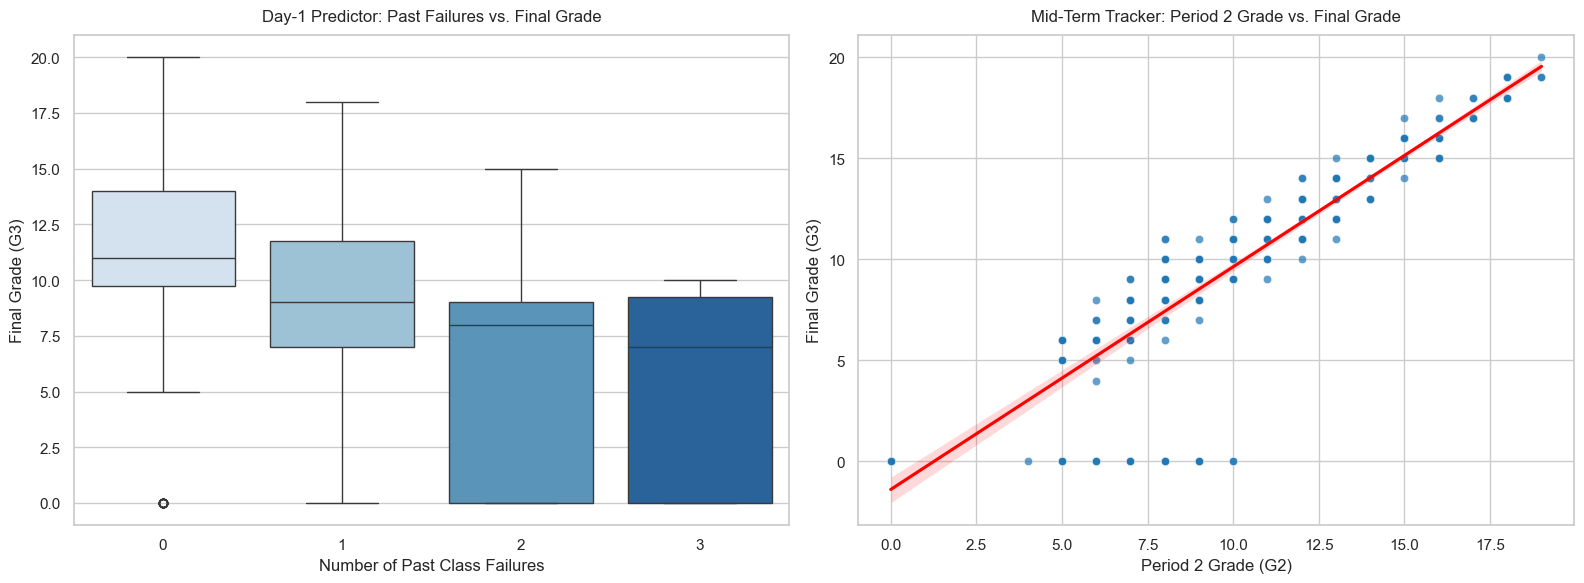

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Day-1 Predictor (Past Failures vs Final Grade)
sns.boxplot(x='failures', y='G3', data=df_analytical, ax=ax1, palette="Blues")
ax1.set_title("Day-1 Predictor: Past Failures vs. Final Grade", fontsize=12, pad=10)
ax1.set_xlabel("Number of Past Class Failures")
ax1.set_ylabel("Final Grade (G3)")

# Plot 2: Mid-Term Tracker (G2 vs Final Grade)
sns.scatterplot(x='G2', y='G3', data=df_analytical, alpha=0.7, color="#1f77b4", ax=ax2)
sns.regplot(x='G2', y='G3', data=df_analytical, scatter=False, color="red", ax=ax2)
ax2.set_title("Mid-Term Tracker: Period 2 Grade vs. Final Grade", fontsize=12, pad=10)
ax2.set_xlabel("Period 2 Grade (G2)")
ax2.set_ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### 🌡️ 3. Multivariate Analysis: Dissecting Correlation and Structural Leakage
We generate a correlation matrix matrix focused purely on numerical features. This visualization clearly illustrates the structural leakage risk of including $G1$ and $G2$ in an early-warning system.

C:\Users\User\AppData\Local\Temp\ipykernel_7508\2060099924.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask =  pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns).fillna(False) # Optional: Hide upper triangle for cleaner look


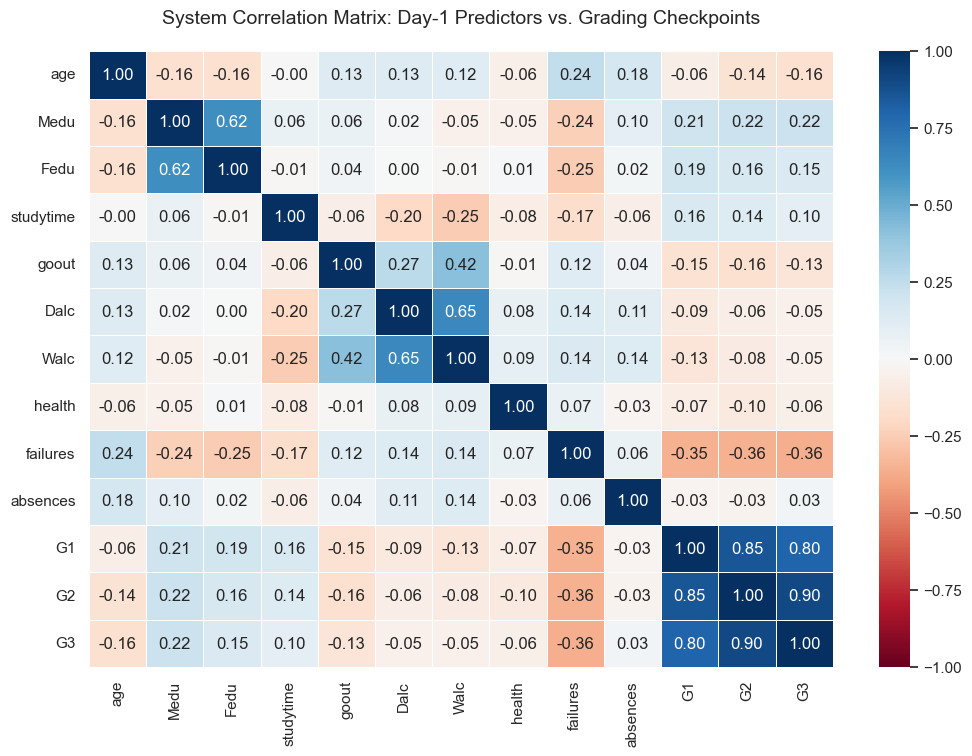

In [5]:
# Filter out non-numeric data for correlation calculation
numeric_cols = ['age', 'Medu', 'Fedu', 'studytime', 'goout', 'Dalc', 'Walc', 'health', 'failures', 'absences', 'G1', 'G2', 'G3']
corr_matrix = df_analytical[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask =  pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns).fillna(False) # Optional: Hide upper triangle for cleaner look
sns.heatmap(corr_matrix, annot=True, cmap="RdBu", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("System Correlation Matrix: Day-1 Predictors vs. Grading Checkpoints", fontsize=14, pad=20)
plt.show()